# Do sportsbook stocks rally *into* the big betting seasons? 🎰
### The "buy DraftKings before the NFL playoffs" trade — a tidy story that the tape doesn't tell

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rally%3F: Busted](https://img.shields.io/badge/Rally%3F-Busted-8b949e?style=flat-square)

Every January and every March, the same idea makes the rounds: the NFL playoffs and March Madness are about to unleash a *wall* of betting handle — record parlays, new-customer promos, deposits pouring in — so the stocks that run the sportsbooks (DraftKings and friends) should rally *ahead* of the games, as the market prices the coming boom.

And the boom is real: Americans really do bet far more in the NFL/March window than in the summer. So the premise isn't crazy. The question is the *second* step — does that known, calendar-fixed spike in betting actually lift the **stocks** in the weeks before tip-off? Or has an efficient market already priced a schedule everyone can read a year in advance?

That's what we test on **DraftKings' entire public life as an operating company (2020→2026)** and **12 flagship betting seasons** — 6 NFL Wild-Card weekends and 6 March-Madness Round-of-64s.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, the beta-adjusted and basket-wide checks? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — a clinical statistical test of public market-price data. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sportsbook_playoffs import data, strategy as st

EVENTS = data.event_table()
RUN_UP = 10
HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSES = data.load_real()
    DKNG = CLOSES["DKNG"]
    RET = st.daily_returns(DKNG)
    AR = st.abnormal_returns(RET)
    BENCH_RET = st.daily_returns(CLOSES["SPY"])
    AR_MADJ = st.abnormal_returns(st.market_adjusted_returns(RET, BENCH_RET))
    BASKET, COVERAGE = st.basket_returns(CLOSES, data.BASKET_TICKERS)
    AR_BASKET = st.abnormal_returns(BASKET)
    AR_BETZ = st.abnormal_returns(st.daily_returns(CLOSES["BETZ"]))
else:
    CLOSES = DKNG = RET = AR = AR_MADJ = BASKET = COVERAGE = AR_BASKET = AR_BETZ = None
print("real cache present:", HAVE_REAL, "| betting seasons in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n': 12, 'cal_lo': '2021-01-09', 'cal_hi': '2026-03-19', 'run_up': 10, 'run_up_pct': -1.93, 'run_up_t': -0.55, 'hits': 5, 'hit_n': 12, 'hit_pct': 41.7, 'wilson': (19.3, 68.0), 'boot': (-8.37, 4.63), 'placebo_mean_pct': -0.038, 'placebo_sd_pct': 3.59, 'placebo_p': 0.698, 'placebo_draws': 20000, 'nfl': (-0.76, -0.14, 6, 3), 'ncaa': (-3.1, -0.63, 6, 2), 'welch': 0.32, 'madj_mean': -1.28, 'madj_t': -0.41, 'basket_mean': -3.24, 'basket_t': -1.19, 'basket_hits': 3, 'basket_wilson': (8.9, 53.2), 'betz_mean': -1.24, 'betz_t': -0.74, 'betz_hits': 4, 'post_mean': -2.8, 'post_t': -1.03, 'event': {-10: (-171.7, -171.7, -1.54), -9: (-193.8, -365.5, -2.76), -8: (-207.4, -572.9, -1.45), -7: (156.7, -416.2, 1.41), -6: (91.4, -324.8, 1.14), -5: (-73.3, -398.1, -0.88), -4: (-8.9, -407.0, -0.07), -3: (-52.1, -459.1, -0.61), -2: (91.5, -367.7, 0.82), -1: (174.2, -193.4, 1.19), 0: (127.7, -65.8, 1.54), 1: (-77.9, -143.7, -0.93), 2: (-61.1, -204.8, -0.61), 3: (34.8, -169.9, 0.32), 4: (-245.5, -415.5, -2.09), 5: (-58.2, -473.7, -0.72)}, 'timer': {5: (245.9, 235.9, 215.9, 0.87, 50), 10: (52.2, 42.2, 22.2, 0.07, 42), 20: (-178.2, -188.2, -208.2, -0.54, 58)}, 'syn_null_mean': 0.14, 'syn_null_sd': 0.63, 'syn_null_fire': 0, 'syn_planted_mean': 14.2, 'syn_planted_t': 4.37, 'fp_dkng': '72bd1b0f5d55', 'fp_penn': 'e888bef384fc', 'fp_czr': '48824d07b05a', 'fp_mgm': '9ca308e4bd97', 'fp_rsi': '793daf5af45c', 'fp_betz': '5438abdf1003', 'fp_spy': 'c33b73c750b6'}


real cache present: True | betting seasons in table: 12


## The answer first

| Question | Answer |
|---|---|
| Do the stocks rally into the season? | **No — the opposite, if anything.** DraftKings' average move over the ~2 weeks *before* the first game is **-1.93%** — negative, and statistically nothing (a random pair of weeks beats it about **70%** of the time). |
| Is it just an NFL thing, or a March thing? | **Neither.** Both seasons drift *down* into the games on their own (NFL -0.76%, March Madness -3.10%). |
| Does the whole betting sector do better? | **No.** The 5-name basket (-3.24%) and the BETZ pure-play ETF (-1.24%) drift down too. |
| Could you trade it? | **No edge to trade.** "Buy the run-up" produces no cost-surviving profit at any horizon we tried. |

> The *betting* really does spike on schedule. The tradable *stock rally* the folklore bolts onto it does not.

## 1 · The claim

> *"NFL playoffs and March Madness are the Super Bowl and the World Cup of the betting business — the two biggest handle events of the year. Anticipation of that flood of wagering should be priced into DraftKings and the sportsbook names in the weeks *before* the games, so you buy the run-up and ride the hype into tip-off."*

This is a fixture of betting-industry trade press and broker previews every autumn and January. It has a real, checkable premise — betting *activity* is strongly seasonal — and a plausible-sounding mechanism (markets price ahead). We take the strongest version: not "the stocks are volatile around the games" but "they systematically **rally into** them."

## 2 · So what? — and is the premise even true?

First, the honest half of the story: US sports-betting **handle** really is seasonal. Here's the shape the industry reports every year (an illustrative, clearly-labelled approximation of American Gaming Association / state-regulator monthly handle — *not* market data, never traded, just to show the premise is real).

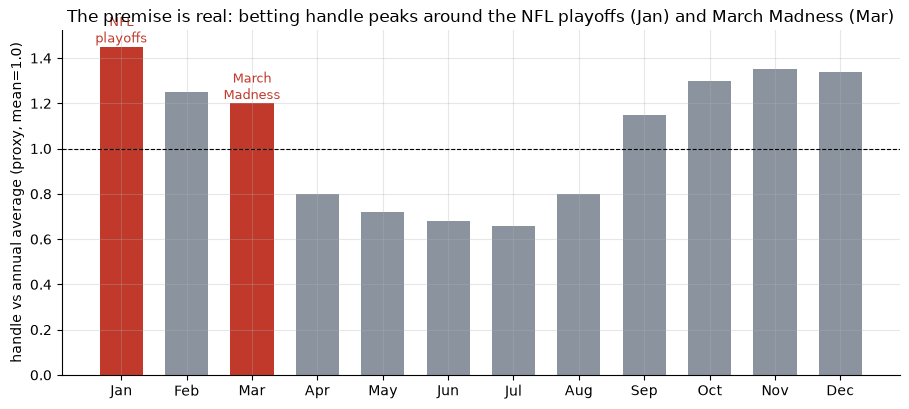

LABELLED PROXY (AGA / state-regulator seasonal shape) — illustrative, not traded


In [2]:
months = list(range(1, 13))
seas = [data.HANDLE_SEASONALITY[m] for m in months]
names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(9.2, 4.2))
cols = [RED if m in (1, 3) else GREY for m in months]
ax.bar(names, seas, color=cols, width=.66)
ax.axhline(1.0, c='k', lw=.8, ls='--')
ax.set_ylabel('handle vs annual average (proxy, mean=1.0)')
ax.set_title('The premise is real: betting handle peaks around the NFL playoffs (Jan) '
             'and March Madness (Mar)')
ax.annotate('NFL\nplayoffs', (0, seas[0]), ha='center', va='bottom', fontsize=9, color=RED)
ax.annotate('March\nMadness', (2, seas[2]), ha='center', va='bottom', fontsize=9, color=RED)
plt.tight_layout(); plt.show()
print('LABELLED PROXY (AGA / state-regulator seasonal shape) — illustrative, not traded')

So if the stocks *did* price this in ahead of time, it would be a clean little seasonal edge: a known calendar, a known catalyst, buy two weeks early. That's worth checking — and it's exactly the kind of "obvious" trade that an efficient market tends to have already eaten.

So we ask three plain things: does DraftKings actually rally into the season, does the rest of the betting sector, and could you have made money buying the run-up?

## 3 · How would we even know?

- **The calendar.** **12** flagship betting-season starts — 6 NFL Wild-Card weekends and 6 March-Madness Round-of-64s, 2021-01-09 to 2026-03-19. That's every one since DraftKings became a real public company (its SPAC merger closed April 2020).
- **The run-up.** DraftKings' return over the **10 trading days just before** the first game, measured against its *own* average (so a "rally" means faster than usual, not just "the stock went up").
- **The luck check.** Draw 12 random dates instead, 20,000 times — how often does a random pair of weeks produce a run-up this big *or bigger*?
- **The sector check.** Same test on a 5-name betting basket (DraftKings/Penn/Caesars/MGM/Rush Street) and on BETZ, the pure-play sports-betting ETF.
- **The trade check.** Buy the run-up, sell before the first game, pay costs, see if anything's left.

**No look-ahead, and none needed:** the NFL and NCAA schedules are public months ahead, so "buy N days before the first game" uses only dates you'd have known a year in advance.

## 4 · The teardown — let's actually look

**First, the headline.** DraftKings' average run-up into a betting season, vs. what a random stretch of the same length looks like.

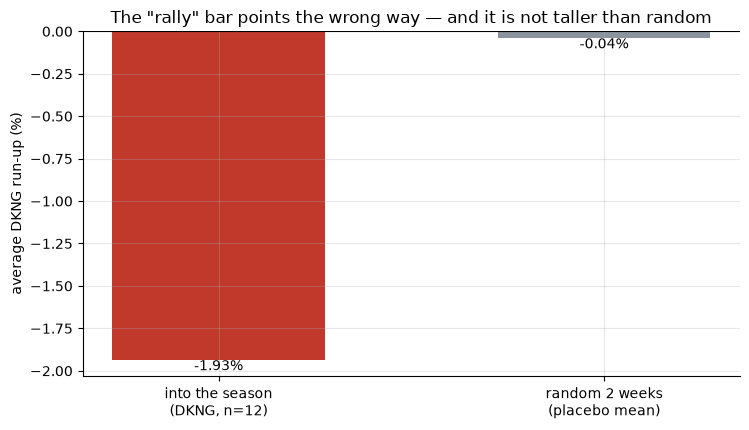

run-up into the season -1.93% vs random -0.04%


In [3]:
if HAVE_REAL:
    r = st.run_up_stats(AR, EVENTS['date'], run_up=RUN_UP)
    run_up_pct = r['mean'] * 100
else:
    run_up_pct = R['run_up_pct']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['into the season\n(DKNG, n=12)', 'random 2 weeks\n(placebo mean)'],
       [run_up_pct, R['placebo_mean_pct']], color=[RED, GREY], width=.55)
for i, v in enumerate([run_up_pct, R['placebo_mean_pct']]):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center',
                va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average DKNG run-up (%)')
ax.set_title('The "rally" bar points the wrong way — and it is not taller than random')
plt.tight_layout(); plt.show()
print(f'run-up into the season {run_up_pct:+.2f}% vs random {R["placebo_mean_pct"]:+.2f}%')

That's the whole story in one chart: **-1.93%** on the average run-up — *negative*, the opposite of a rally — and barely different from **-0.04%** on a random stretch. DraftKings rallied into only **5/12 = 42%** of these seasons — a coin flip. A random calendar beats this about 70% of the time.

**Maybe it's really an NFL thing, or a March thing?** Let's split them.

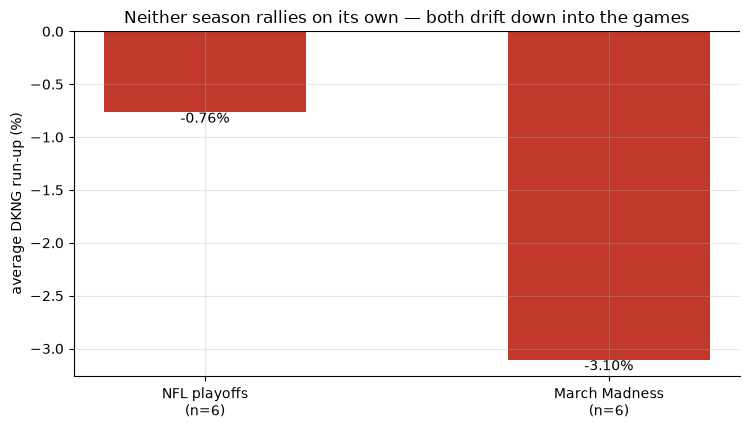

NFL -0.76%  vs  March Madness -3.10%


In [4]:
if HAVE_REAL:
    nfl = st.run_up_stats(AR, EVENTS[EVENTS['family']=='NFL']['date'], run_up=RUN_UP)
    ncaa = st.run_up_stats(AR, EVENTS[EVENTS['family']=='NCAA']['date'], run_up=RUN_UP)
    vals = [nfl['mean']*100, ncaa['mean']*100]
else:
    vals = [R['nfl'][0], R['ncaa'][0]]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['NFL playoffs\n(n=6)', 'March Madness\n(n=6)'], vals,
       color=[RED, RED], width=.5)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average DKNG run-up (%)')
ax.set_title('Neither season rallies on its own — both drift down into the games')
plt.tight_layout(); plt.show()
print(f'NFL {vals[0]:+.2f}%  vs  March Madness {vals[1]:+.2f}%')

Nope — both are negative and both are noise. There's no "it's really the NFL" rescue hiding inside the average.

**Is it just DraftKings, or the whole sector?** Let's widen to a 5-name betting basket and the BETZ pure-play ETF.

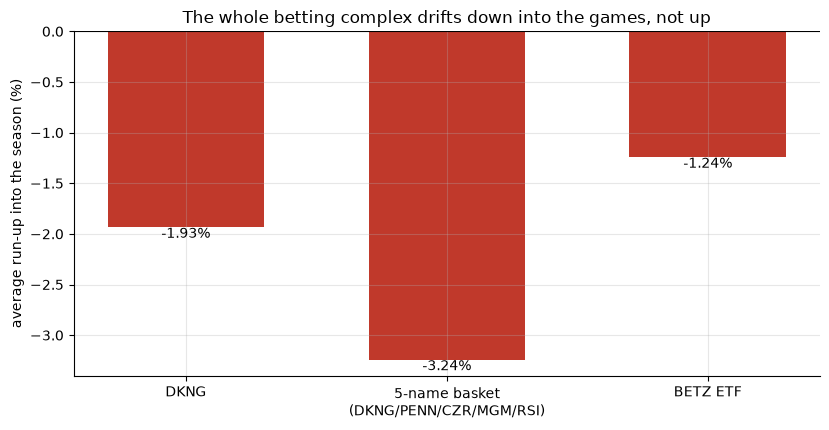

DKNG -1.93%  basket -3.24%  BETZ -1.24%


In [5]:
if HAVE_REAL:
    rb = st.run_up_stats(AR_BASKET, EVENTS['date'], run_up=RUN_UP)
    re = st.run_up_stats(AR_BETZ, EVENTS['date'], run_up=RUN_UP)
    vals = [run_up_pct, rb['mean']*100, re['mean']*100]
else:
    vals = [R['run_up_pct'], R['basket_mean'], R['betz_mean']]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['DKNG', '5-name basket\n(DKNG/PENN/CZR/MGM/RSI)', 'BETZ ETF'], vals,
       color=[RED, RED, RED], width=.6)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average run-up into the season (%)')
ax.set_title('The whole betting complex drifts down into the games, not up')
plt.tight_layout(); plt.show()
print(f'DKNG {vals[0]:+.2f}%  basket {vals[1]:+.2f}%  BETZ {vals[2]:+.2f}%')

Widening the net makes it slightly *worse*, not better — the diversified basket drifts down a touch more than DraftKings alone. Whatever the folklore is describing, it isn't in the tape.

**Finally, the trade.** Could you have made money buying the run-up?

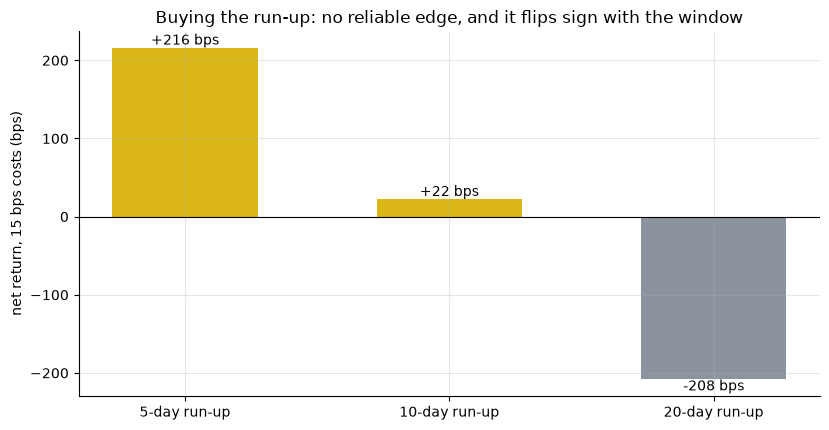

net (15 bps) by run-up: {5: 216, 10: 22, 20: -208}


In [6]:
if HAVE_REAL:
    holds = [5, 10, 20]
    net = []
    for h in holds:
        lg = st.run_up_timer(DKNG, EVENTS['date'], run_up=h, cost_bps=15.0)
        net.append(st.summarize_timer(lg, 'ret_net')['mean_bps'])
else:
    holds = [5, 10, 20]
    net = [R['timer'][h][2] for h in holds]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar([f'{h}-day run-up' for h in holds], net,
       color=[GREY if v <= 0 else AMBER for v in net], width=.55)
for i, v in enumerate(net):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v > 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net return, 15 bps costs (bps)')
ax.set_title('Buying the run-up: no reliable edge, and it flips sign with the window')
plt.tight_layout(); plt.show()
print('net (15 bps) by run-up:', dict(zip(holds, [round(v) for v in net])))

The only positive bar (the 5-day run-up, **+216 bps** net) comes with a *t* of just **0.87** and a **50%** win rate over 12 events — a coin flip that happened to land heads — and it **flips to a loss** as you lengthen the window. Stretch it to 20 days and you're down **208 bps**. There's no stable edge to trade, and nothing for costs to eat because there was nothing there to begin with.

## 5 · The verdict

- **Signal — None.** DraftKings' run-up into a betting season is **-1.93%** (*wrong sign*), a coin-flip hit rate, and a random calendar reproduces it ~70% of the time. The basket, the ETF and the market-adjusted version all agree; neither season rescues it.
- **Tradability — Mirage.** No cost-surviving edge at any horizon; the one positive point estimate is noise that flips sign as the window widens.
- **"Do betting stocks rally into the season?" — Busted.** The handle seasonality is real; the tradable stock-price rally isn't.

## 6 · Going further 🚪

- **A schedule everyone can read a year ahead is the least likely thing to surprise a market.** The cleanest reading of this null: the betting-season calendar is *maximally* public, so if there were an easy pre-season rally it would have been arbitraged into the earlier weeks (or into the *prior* off-season) long ago. Efficient-markets 1, folklore 0.
- **Where a real version might live:** the *surprise* component — a season that shatters handle records vs. a merely-typical one — measured against *analyst expectations* rather than the calendar, or the earnings prints that actually report the handle a month or two later. That's a fundamentals event study, not a calendar one, and a different study.
- **Short history is the honest limit.** DraftKings has only ~6 years and 12 flagship seasons as a public company; a small, real seasonal tilt could be invisible at n=12. The honest conclusion is "not detectable, wrong sign, at this size on this tape", not "provably impossible forever."
- **Sibling studies:** [707-plane-crash-effect](../../707-plane-crash-effect/) and [708-eurovision-effect](../../708-eurovision-effect/) (the same event-study machinery on other folklore) and [300-sports-sentiment](../../300-sports-sentiment/) (sports *results* moving the *home* market).

*Think the surprise-vs-expectation version has a pulse? Show it — out of sample, after costs — then we'll talk.*